# Глубинное обучение 1 / Введение в глубинное обучение, ФКН ВШЭ

## Домашнее задание 1. Часть 2: полносвязные нейронные сети. 

### Общая информация

Оценка после штрафа после мягкого дедлайна вычисляется по формуле $M_{\text{penalty}} = M_{\text{full}} \cdot 0.85^{t/1440}$, где $M_{\text{full}}$ — полная оценка за работу без учета штрафа, а $t$ — время в минутах, прошедшее после мягкого дедлайна (округление до двух цифр после запятой). Таким образом, спустя первые сутки после мягкого дедлайна вы не можете получить оценку выше 8.5, а если сдать через четыре дня после мягкого дедлайна, то ваш максимум — 5.22 балла.

### Оценивание и штрафы

Максимально допустимая оценка за работу — 10 баллов. Сдавать задание после указанного срока сдачи нельзя.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

### О задании

В этой части мы будем использовать фреймворк для обучения нейронный сетей, который вы реализовали в первой половине задания. А именно, вам предстоит обучить полносвязную нейронную сеть для предсказания года выпуска песни по ее аудио-признакам. Для этого мы будем использовать [Million Songs Dataset](https://samyzaf.com/ML/song_year/song_year.html). Если по какой-то причине вы не сделали первую половину домашки, то **можете поставить все эксперименты на PyTorch**, но рекомендуется использовать ваши реализации модулей. 

In [3]:
import sys
!{sys.executable} -m pip install numpy pandas matplotlib seaborn tqdm ipywidgets scikit-learn


In [4]:
!jupyter labextension install @jupyter-widgets/jupyterlab-manager


(Deprecated) Installing extensions with the jupyter labextension install command is now deprecated and will be removed in a future major version of JupyterLab.

Users should manage prebuilt extensions with package managers like pip and conda, and extension authors are encouraged to distribute their extensions as prebuilt packages 
Building jupyterlab assets (production, minimized)


In [3]:
import modules as mm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from IPython.display import clear_output

plt.rcParams.update({'font.size': 16})
sns.set_style('whitegrid')
np.random.seed(0xFA1AFE1)

Начнем с того, что скачаем и загрузим данные:

In [7]:
!wget -O data.txt.zip https://archive.ics.uci.edu/ml/machine-learning-databases/00203/YearPredictionMSD.txt.zip

--2025-11-16 12:01:46--  https://archive.ics.uci.edu/ml/machine-learning-databases/00203/YearPredictionMSD.txt.zip
Распознаётся archive.ics.uci.edu (archive.ics.uci.edu)… 128.195.10.252
Подключение к archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... соединение установлено.
HTTP-запрос отправлен. Ожидание ответа… 200 OK
Длина: нет данных
Сохранение в: «data.txt.zip»

data.txt.zip            [    <=>             ] 201,24M  2,63MB/s    за 72s     

2025-11-16 12:03:00 (2,81 MB/s) - «data.txt.zip» сохранён [211011981]



In [4]:
df = pd.read_csv('data.txt.zip')
df

,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
0,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
1,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
2,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
3,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903
4,2001,50.54767,0.31568,92.35066,22.38696,-25.51870,-19.04928,20.67345,-5.19943,3.63566,...,6.59753,-50.69577,26.02574,18.94430,-0.33730,6.09352,35.18381,5.00283,-11.02257,0.02263
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515339,2006,51.28467,45.88068,22.19582,-5.53319,-3.61835,-16.36914,2.12652,5.18160,-8.66890,...,4.81440,-3.75991,-30.92584,26.33968,-5.03390,21.86037,-142.29410,3.42901,-41.14721,-15.46052
515340,2006,49.87870,37.93125,18.65987,-3.63581,-27.75665,-18.52988,7.76108,3.56109,-2.50351,...,32.38589,-32.75535,-61.05473,56.65182,15.29965,95.88193,-10.63242,12.96552,92.11633,10.88815
515341,2006,45.12852,12.65758,-38.72018,8.80882,-29.29985,-2.28706,-18.40424,-22.28726,-4.52429,...,-18.73598,-71.15954,-123.98443,121.26989,10.89629,34.62409,-248.61020,-6.07171,53.96319,-8.09364
515342,2006,44.16614,32.38368,-3.34971,-2.49165,-19.59278,-18.67098,8.78428,4.02039,-12.01230,...,67.16763,282.77624,-4.63677,144.00125,21.62652,-29.72432,71.47198,20.32240,14.83107,39.74909


Посмотрим на статистики по данным.

In [7]:
df.describe()

,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
count,515344.000000,515344.000000,515344.000000,515344.000000,515344.000000,515344.000000,515344.000000,515344.000000,515344.000000,515344.000000,...,515344.000000,515344.000000,515344.000000,515344.000000,515344.000000,515344.000000,515344.000000,515344.000000,515344.000000,515344.000000
mean,1998.397077,43.387113,1.289515,8.658222,1.164110,-6.553580,-9.521968,-2.391046,-1.793215,3.727868,...,15.755411,-73.461537,41.542388,37.934163,0.315750,17.669292,-26.315520,4.458653,20.035229,1.329104
std,10.931056,6.067557,51.580393,35.268505,16.322802,22.860803,12.857763,14.571853,7.963822,10.582869,...,32.099666,175.619058,122.228915,95.050718,16.161780,114.428002,173.977455,13.346567,185.558415,22.088598
min,1922.000000,1.749000,-337.092500,-301.005060,-154.183580,-181.953370,-81.794290,-188.214000,-72.503850,-126.479040,...,-437.722030,-4402.376440,-1810.689190,-3098.350310,-341.789120,-3168.924570,-4319.992320,-236.039260,-7458.378150,-381.424430
25%,1994.000000,39.954667,-26.059848,-11.462775,-8.487507,-20.666455,-18.441005,-10.780360,-6.468390,-2.293670,...,-1.812658,-139.555737,-20.987115,-4.669655,-6.781598,-31.580617,-101.530305,-2.566137,-59.509453,-8.820248
50%,2002.000000,44.258490,8.417725,10.476235,-0.652855,-6.007770,-11.188355,-2.046625,-1.736415,3.822305,...,9.171850,-53.089115,28.790580,33.623815,0.820830,15.598520,-21.204225,3.117645,7.759910,0.053015
75%,2006.000000,47.833875,36.124030,29.764685,8.787548,7.741877,-2.388945,6.508587,2.913455,9.961865,...,26.274487,13.478793,89.661785,77.785810,8.471000,67.795110,52.389322,9.967742,86.351645,9.679540
max,2011.000000,61.970140,384.065730,322.851430,335.771820,262.068870,166.236890,172.402680,126.741270,146.297950,...,840.973380,4469.454870,3210.701700,1734.079690,260.544900,3662.065650,2833.608950,463.419500,7393.398440,677.899630


Целевая переменная, год выпуска песни, записана в первом столбце. Посмотрим на ее распределение.

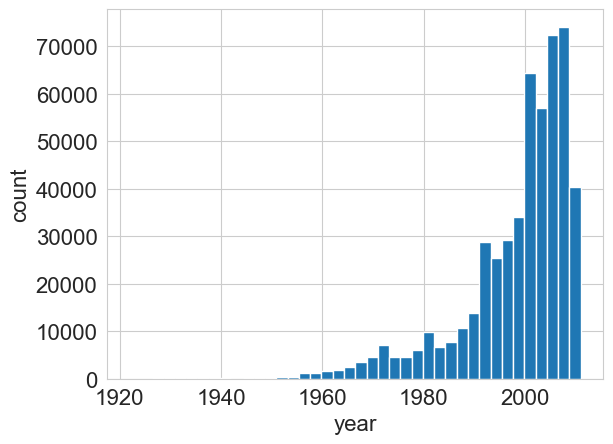

Range: 1922 - 2011
Unique values: 89


In [4]:
plt.hist(df.iloc[:, 0], bins=40)
plt.xlabel('year')
plt.ylabel('count')
plt.show()
print(f'Range: {df.iloc[:, 0].min()} - {df.iloc[:, 0].max()}')
print(f'Unique values: {np.unique(df.iloc[:, 0]).size}')

Разобьем данные на обучение и тест (не меняйте здесь ничего, чтобы сплит был одинаковым у всех).

In [7]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

train_size = int(0.75 * X.shape[0])
X_train = X[:train_size, :]
y_train = y[:train_size]
X_test = X[train_size:, :]
y_test = y[train_size:]
X_train.shape, X_test.shape

((386508, 90), (128836, 90))

**Задание 0 (0 баллов, но при невыполнении максимальная оценка за всю работу &mdash; 0 баллов).** Мы будем использовать MSE как метрику качества. Прежде чем обучать нейронные сети, нам нужно проверить несколько простых бейзлайнов, чтобы было с чем сравнить более сложные алгоритмы. Для этого бучите `Ridge` регрессию из `sklearn`. Кроме того, посчитайте качество при наилучшем константном прогнозе.

In [100]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#для модели из склерна
ridge_model = Ridge()
ridge_model.fit(X_train, y_train)

y_pred = ridge_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'для модели в sklearn {mse},{rmse},{mae},{r2}')

#для константной модели
y_pred_simple = y_train.mean()

mse_simple = np.mean((y_test-y_pred_simple)**2)
rmse_simple = mse_simple**0.5
mae_simple = np.mean(abs(y_test-y_pred_simple))
r2_simple = 1 - np.sum((y_test-y_pred_simple)**2)/(np.sum((y_test-y_test.mean())**2))
print(f'для модели = const {mse_simple},{rmse_simple},{mae_simple},{r2_simple}')

для модели в sklearn 89.74911055972669,9.473600717769706,6.756419876086483,0.23694881696428316
для модели = const 117.62626181741031,10.845564153948393,8.137262422198067,-6.40415941881578e-05


Теперь приступим к экспериментам с нейросетями. Для начала отделим от данных валидацию:

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=0xE2E4)
X_train.shape, X_val.shape

((289881, 90), (96627, 90))

## Глава I. Заводим нейронную сеть (5 баллов)

**Задание 1.1 (0.5 баллов).** Заполните пропуски в функции `train_and_validate`. Она поможет нам запускать эксперименты.

In [5]:
def plot_losses(train_losses, train_metrics, val_losses, val_metrics):
    """
    Plot losses and metrics while training
      - train_losses: sequence of train losses
      - train_metrics: sequence of train MSE values
      - val_losses: sequence of validation losses
      - val_metrics: sequence of validation MSE values
    """
    clear_output()
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))
    axs[0].plot(range(1, len(train_losses) + 1), train_losses, label='train')
    axs[0].plot(range(1, len(val_losses) + 1), val_losses, label='val')
    axs[1].plot(range(1, len(train_metrics) + 1), train_metrics, label='train')
    axs[1].plot(range(1, len(val_metrics) + 1), val_metrics, label='val')

    if max(train_losses) / min(train_losses) > 10:
        axs[0].set_yscale('log')

    if max(train_metrics) / min(train_metrics) > 10:
        axs[0].set_yscale('log')

    for ax in axs:
        ax.set_xlabel('epoch')
        ax.legend()

    axs[0].set_ylabel('loss')
    axs[1].set_ylabel('MSE')
    plt.show()


def train_and_validate(model, optimizer, criterion, metric, train_loader, val_loader,
                       num_epochs, verbose=True):
    """
    Train and validate neural network
      - model: neural network (mm.Module) to train
      - optimizer: optimizer (mm.Optimizer) chained to a model
      - criterion: loss function class (mm.Criterion)
      - metrics: function to measure MSE taking neural networks predictions
                 and ground truth labels
      - train_loader: mm.DataLoader with train set
      - val_loader: mm.DataLoader with validation set
      - num_epochs: number of epochs to train
      - verbose: whether to plot metrics during training
    Returns:
      - train_mse: training MSE over the last epoch
      - val_mse: validation MSE after the last epoch
    """
    train_losses, val_losses = [], []
    train_metrics, val_metrics = [], []

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss, running_metric = 0, 0
        pbar = tqdm(train_loader, desc=f'Training {epoch}/{num_epochs}') \
            if verbose else train_loader

        for X_batch, y_batch in pbar:
            '''
            YOUR CODE HERE (－.－)...zzzZZZzzzZZZ
            Do forward and backward passes
            predictions = ...
            loss = ...
            '''
            predictions = model(X_batch)
            loss = criterion.compute_output(predictions, y_batch)

            model.zero_grad()
            grad = criterion.compute_grad_input(predictions, y_batch)
            model.backward(X_batch, grad)
            optimizer.step()

            metric_value = metric(predictions, y_batch)
            running_loss += loss * X_batch.shape[0]
            running_metric += metric_value * X_batch.shape[0]
            if verbose:
                pbar.set_postfix({'loss': loss, 'MSE': metric_value})

        train_losses += [running_loss / train_loader.num_samples()]
        train_metrics += [running_metric / train_loader.num_samples()]

        model.eval()
        running_loss, running_metric = 0, 0
        pbar = tqdm(val_loader, desc=f'Validating {epoch}/{num_epochs}') \
            if verbose else val_loader

        for X_batch, y_batch in pbar:
            '''
            YOUR CODE HERE (－.－)...zzzZZZzzzZZZ
            Do evaluation
            predictions = ...
            loss = ...
            '''
            predictions = model(X_batch)
            loss = criterion.compute_output(predictions, y_batch)
                        
            
            metric_value = metric(predictions, y_batch)
            running_loss += loss * X_batch.shape[0]
            running_metric += metric_value * X_batch.shape[0]
        if verbose:
            pbar.set_postfix({'loss': loss, 'MSE': metric_value})

        val_losses += [running_loss / val_loader.num_samples()]
        val_metrics += [running_metric / val_loader.num_samples()]

        if verbose:
            plot_losses(train_losses, train_metrics, val_losses, val_metrics)
    
    if verbose:
        print(f'Validation MSE: {val_metrics[-1]:.3f}')
    
    return train_metrics[-1], val_metrics[-1], train_losses, val_losses, train_metrics, val_metrics
#сделал вывод чуть удобнее чтобы юпитер не падал и графиик можно было в конце просто рисовать

**Задание 1.2 (0.75 балла).** Попробуем обучить нашу первую нейронную сеть. Здесь целевая переменная дискретная &mdash; это год выпуска песни. Поэтому будем учить сеть на классификацию.

- В качестве архитектуры сети возьмите два линейных слоя с активацией ReLU между ними c числом скрытых нейронов, равным 128.
- Используйте SGD с `lr=1e-3`.
- Возьмите размер мини-батча около 32-64, примерно 3-4 эпох обучения должно быть достаточно.
- Также преобразуйте целевую переменную так, чтобы ее значения принимали значения от $0$ до $C-1$, где $C$ &mdash; число классов (лучше передайте преобразованное значение в DataLoader, исходное нам еще пригодится)
- В качестве параметра `metric` в `train_and_validate` передайте lambda-выражение, которое считает MSE по выходу нейронной сети и целевой переменной. В случае классификации предсказывается класс с наибольшей вероятностью (или, что то же самое, с наибольшим значением логита).

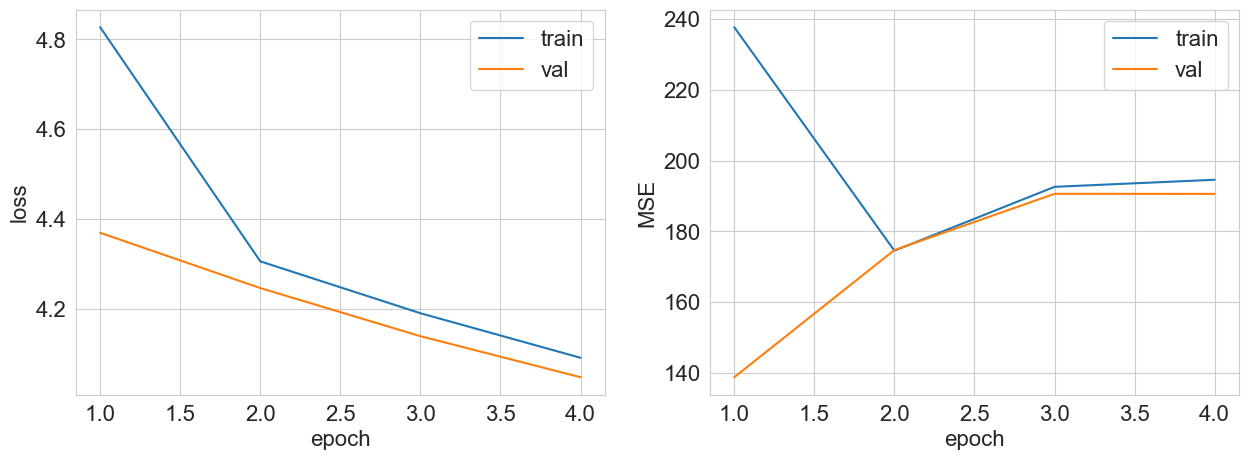

 MSE = 190.57626750287187


In [87]:
np.random.seed(42)

classes = np.unique(y_train)
nom_class = {c: i for i, c in enumerate(classes)}

y_train_norm = np.array([nom_class[c] for c in y_train])
y_test_norm  = np.array([nom_class[c] for c in y_test])

train_loader = mm.DataLoader(X_train, y_train_norm, batch_size=64, shuffle=True)
test_loader  = mm.DataLoader(X_test,  y_test_norm,  batch_size=64, shuffle=False)

model = mm.Sequential(
    mm.Linear(X_train.shape[1], 128),
    mm.ReLU(),
    mm.Linear(128, len(nom_class)),
)

optimizer = mm.SGD(model, lr=1e-3)
criterion  = mm.CrossEntropyLoss()

metric = lambda p, y: np.mean((p.argmax(axis=1) - y)**2)



num_epochs = 4

 train_mse, val_mse, train_losses, val_losses, train_metrics, val_metrics = train_and_validate(model, optimizer, criterion, metric, train_loader, test_loader, num_epochs, verbose=False)

plot_losses(train_losses, train_metrics, val_losses, val_metrics)

print(f' MSE = {val_mse}')


**Задание 1.3 (0.5 балла).** Прокомментируйте ваши наблюдения. Удалось ли побить бейзлайн? Как вы думаете, хорошая ли идея учить классификатор для этой задачи? Почему?

**Ответ:** это фиаско, наша модель не побила даже бейзлан (190 > 117). Проблема скорее всего в том, что мы использовали классификатор, для которого ошибка между 2000 и 1999 = ошибка между 2000 и 1950 годами (то есть важно что года различаются, а как, ему уже все равно), поэтому тут лучше надо было использовать регрессию, потому что она не там сильно будет наказывать за небольшое временное отклонение.

**Задание 1.4 (0.75 балла).** Теперь попробуем решать задачу как регрессию. Обучите нейронную сеть на MSE.

- Используйте такие же гиперпараметры обучения.
- Когда передаете целевую переменную в DataLoader, сделайте reshape в (-1, 1).
- Не забудьте изменить lambda-выражение, которые вы передаете в `train_and_validate`.
- Если что-то пойдет не так, можете попробовать меньшие значения `lr`.

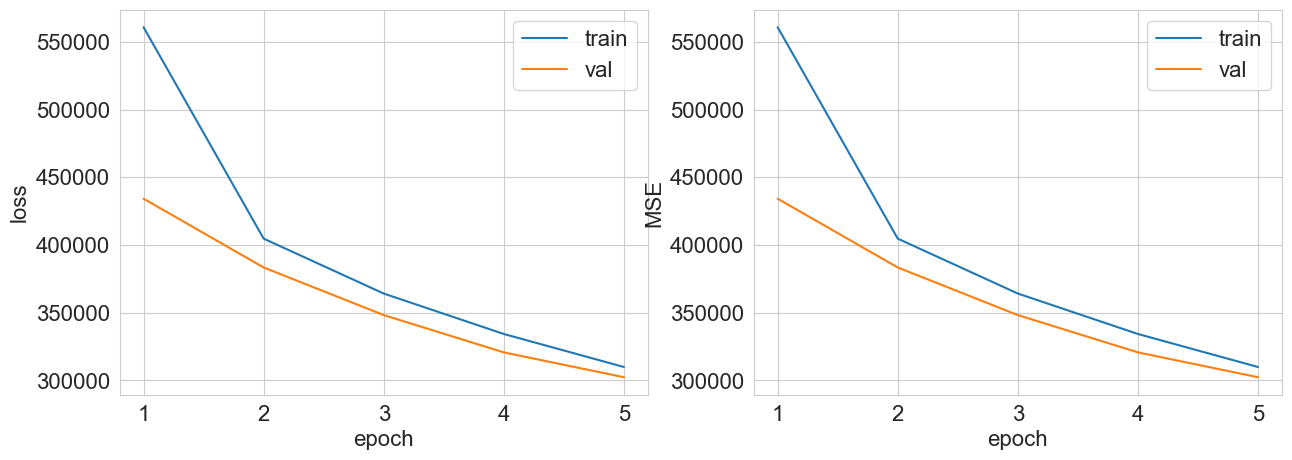

 MSE = 302245.2181691514


In [11]:
np.random.seed(42)

classes = np.unique(y_train)


y_train_new = y_train.reshape(-1, 1)
y_test_new  = y_test.reshape(-1, 1)

train_loader = mm.DataLoader(X_train, y_train_new, batch_size=64, shuffle=True)
test_loader  = mm.DataLoader(X_test,  y_test_new,  batch_size=64, shuffle=False)

model = mm.Sequential(
    mm.Linear(X_train.shape[1], 128),
    mm.ReLU(),
    mm.Linear(128, 1),
)

optimizer = mm.SGD(model, lr=1e-9)
criterion  = mm.MSELoss()

metric = lambda p, y: np.mean((p - y)**2)


num_epochs = 5

train_mse, val_mse, train_losses, val_losses, train_metrics, val_metrics = train_and_validate(model, optimizer, criterion, metric, train_loader, test_loader, num_epochs, verbose=False)

plot_losses(train_losses, train_metrics, val_losses, val_metrics)
print(f' MSE = {val_mse}')


**Задание 1.5 (0.5 балла).** Получилось ли у вас стабилизировать обучение? Помогли ли меньшие значения `lr`? Стало ли лучше от замены классификации на регрессию? Как вы думаете, почему так происходит? В качестве подсказки можете посмотреть на распределение целевой переменной и магнитуду значений признаков.

**Ответ:** тоже какое-то фиаско. MSE получилось при маленьких 'lr' 326075 что явно хуже бейзлана все еще. думаю проблемка в том, что у нас веса почти не меняются потому что 'lr' малюсенький, а разброс в годах огромный (от 1900 до 2006+)

**Задание 1.6 (0.75 балла).** Начнем с того, что попробуем отнормировать целевую переменную. Для этого воспользуемся min-max нормализацией, чтобы целевая переменная принимала значения от 0 до 1. Реализуйте функции `normalize` и `denormalize`, которые, соответственно, нормируют целевую переменную и применяют обратное преобразование. Минимум и максимум оцените по обучающей выборке (то есть эти константы должны быть фиксированными и не зависеть от передаваемой выборки).

In [13]:
def normalize(sample):
    """
    Min-max normalization to convert sample to [0, 1] range
    """
    maX = max(y_train)
    miN = min(y_train)

    return (sample - miN)/(maX - miN) #известный мув

def denormalize(sample):
    """
    Denormalize sample from [0, 1] to initial range
    """
    maX = max(y_train)
    miN = min(y_train)

    return sample*(maX-miN)+miN #просто выразили обратно из предыдущей функции

Теперь повторите эксперимент из **задания 1.4**, обучаясь на нормированной целевой переменной. Сделаем также еще одно изменение: добавим сигмоидную активацию после последнего линейного слоя сети. Таким образом мы гарантируем, что нейронная сеть предсказывает числа из промежутка $[0, 1]$. Использование активации - довольно распространенный прием, когда мы хотим получить числа из определенного диапазона значений. 

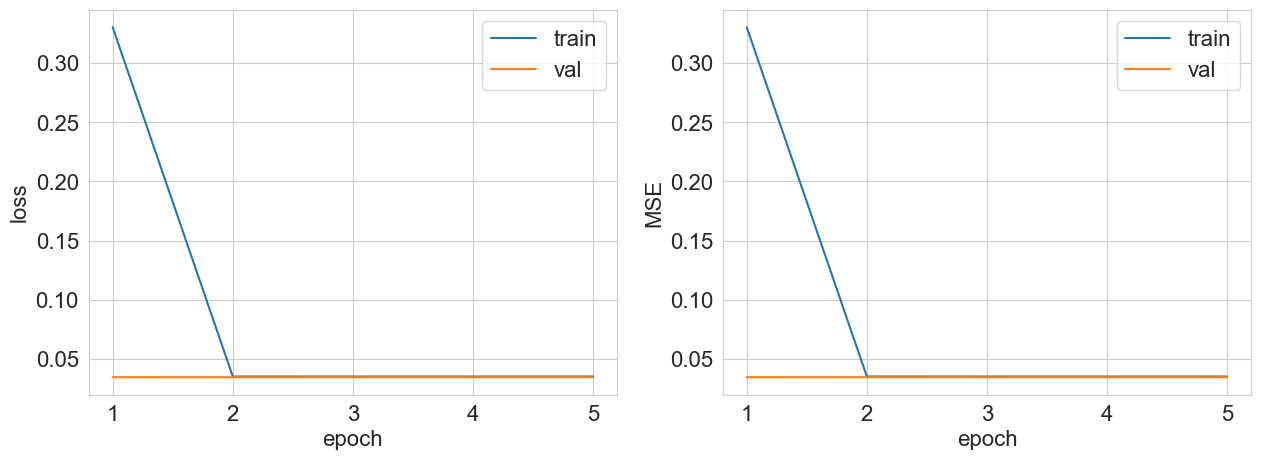

 MSE = 0.03469916613254817
 denorm MSE = 274.85209493591395


In [14]:
np.random.seed(42)




y_train_new = normalize(y_train).reshape(-1, 1)
y_test_new  = normalize(y_test).reshape(-1, 1)

train_loader = mm.DataLoader(X_train, y_train_new, batch_size=64, shuffle=True)
test_loader  = mm.DataLoader(X_test,  y_test_new,  batch_size=64, shuffle=False)

model = mm.Sequential(
    mm.Linear(X_train.shape[1], 128),
    mm.ReLU(),
    mm.Linear(128, 1),
    mm.Sigmoid(),
)

optimizer = mm.SGD(model, lr=1e-3)
criterion  = mm.MSELoss()

metric = lambda p, y: np.mean((p - y)**2)


num_epochs = 5

train_mse, val_mse, train_losses, val_losses, train_metrics, val_metrics = train_and_validate(model, optimizer, criterion, metric, train_loader, test_loader, num_epochs, verbose=False)

plot_losses(train_losses, train_metrics, val_losses, val_metrics)
print(f' MSE = {val_mse}')


predictions = []
targets = []
for X_batch, y_batch in test_loader:
    predictions.append(model(X_batch))
    targets.append(y_batch)

predictions = np.vstack(predictions)          
targets = np.vstack(targets)       

denorm_predictions = denormalize(predictions)
denorm_targets = denormalize(targets)

real_mse = np.mean((denorm_predictions - denorm_targets)**2)
print(f' denorm MSE = {real_mse}')

**Задание 1.7 (0.5 балла).** Сравните результаты этого эксперимента с предыдущим запуском. 

**Ответ:** вот тут уже лучше устранить дисбаланс масштабов признаков. то есть из-за того, что года были отнормированы у нас получилось нивилировать гигантскую разницу между ними, из-за чего изначально градиентный спуск был бесполезен. поэтому когда мы обратно отнормировали mse, то получили более менее результат, потому что веса успели адаптироваться

**Задание 1.8 (0.75 балла).** На этот раз попробуем отнормировать не только целевую переменную, но и сами данные, которые подаются сети на вход. Для них будем использовать нормализацию через среднее и стандартное отклонение. Преобразуйте данные и повторите прошлый эксперимент. Скорее всего, имеет смысл увеличить число эпох обучения.

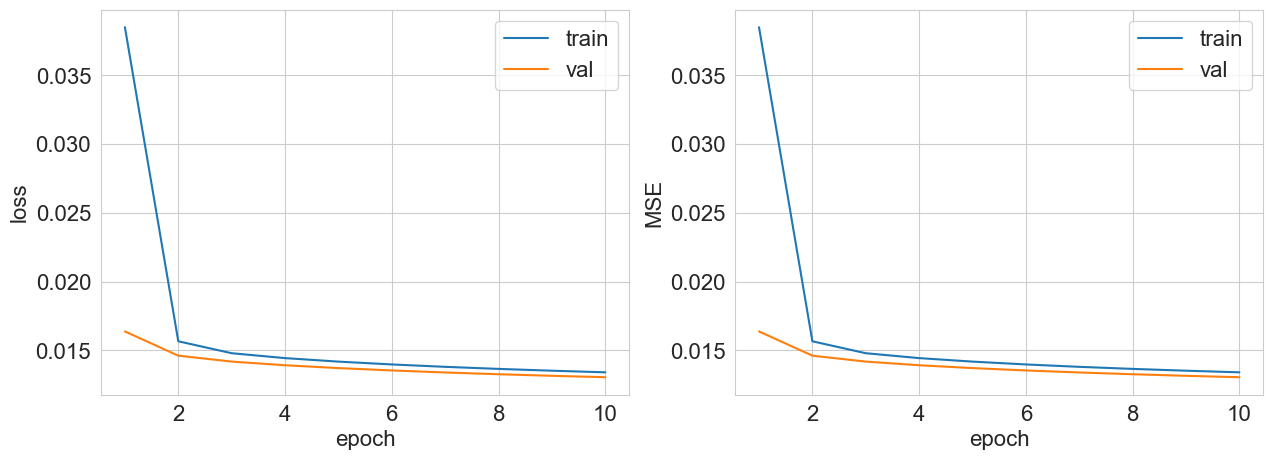

 MSE = 0.013050694995164617
 denorm MSE = 103.37455505669888


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
np.random.seed(42)



X_train_scale = scaler.fit_transform(X_train)
X_test_scale  = scaler.transform(X_test)

y_train_new = normalize(y_train).reshape(-1, 1)
y_test_new  = normalize(y_test).reshape(-1, 1)

train_loader = mm.DataLoader(X_train_scale, y_train_new, batch_size=64, shuffle=True)
test_loader  = mm.DataLoader(X_test_scale,  y_test_new,  batch_size=64, shuffle=False)

model = mm.Sequential(
    mm.Linear(X_train_scale.shape[1], 128),
    mm.ReLU(),
    mm.Linear(128, 1),
    mm.Sigmoid(),
)

optimizer = mm.SGD(model, lr=1e-3)
criterion  = mm.MSELoss()

metric = lambda p, y: np.mean((p - y)**2)


num_epochs = 10

train_mse, val_mse, train_losses, val_losses, train_metrics, val_metrics = train_and_validate(model, optimizer, criterion, metric, train_loader, test_loader, num_epochs, verbose=False)

plot_losses(train_losses, train_metrics, val_losses, val_metrics)
print(f' MSE = {val_mse}')


predictions = []
targets = []
for X_batch, y_batch in test_loader:
    predictions.append(model(X_batch))
    targets.append(y_batch)

predictions = np.vstack(predictions)          
targets = np.vstack(targets)       

denorm_predictions = denormalize(predictions)
denorm_targets = denormalize(targets)

real_mse = np.mean((denorm_predictions - denorm_targets)**2)
print(f' denorm MSE = {real_mse}')

Если вы все сделали правильно, то у вас должно было получиться качество, сравнимое с `Ridge` регрессией.

**Мораль:** как видите, нам пришлось сделать очень много хитрых телодвижений, чтобы нейронная сеть работала хотя бы так же, как и простая линейная модель. Здесь, конечно, показан совсем экстремальный случай, когда без нормализации данных нейронная сеть просто не учится. Как правило, в реальности завести нейронную сеть из коробки не очень сложно, но вот заставить ее работать на полную &mdash; куда более трудоемкая задача. Написание пайплайнов обучения нейросетевых моделей требует большой аккуратности, а дебаг часто превращается в угадайку. К счастью, очень часто на помощь приходит интуиция, и мы надеемся, что вы сможете выработать ее в течение нашего курса. Начнем с двух советов, которые стоит принять на вооружение:

- Обязательно начинаем любые эксперименты с бейзлайнов: без них мы бы не поняли, что нейронная сеть не учится в принципе.
- При постановке эксперментов старайтесь делать минимальное количество изменений за раз (в идеале одно!): только так можно понять, какие конкретно изменения влияют на результат.

## Часть 2. Улучшаем нейронную сеть

Продолжим экспериментировать с нейронной сетью, чтобы добиться еще лучшего качества. В заданиях 2.1-2.3 **запускайте эксперименты несколько раз (4-5)** с одинаковыми значениями гиперпараметров обучения, но с разными случайными инициализациями сети (достаточно просто прогнать код с инициализацией модели и ее обучением в цикле: каждый вызов конструктора инициализирует модель случайно). Для сравнения качества разных экспериментов **отрисовывайте ящики с усами (boxplot)** по этим нескольким запускам.

Задание 2.4 требует перебора гиперпараметров, в нем запускайте эксперимент по одному разу для каждого рассмотренного значения, чтобы сэкономить время.

**Задание 2.1 (1 балл).** Давайте попробуем другие оптимизаторы. Обучите нейросеть с помощью SGD+momentum и Adam. Опишите свои наблюдения и в дальнейших запусках используйте лучший оптимизатор. Для Adam обычно берут learning rate поменьше, в районе $10^{-3}$.

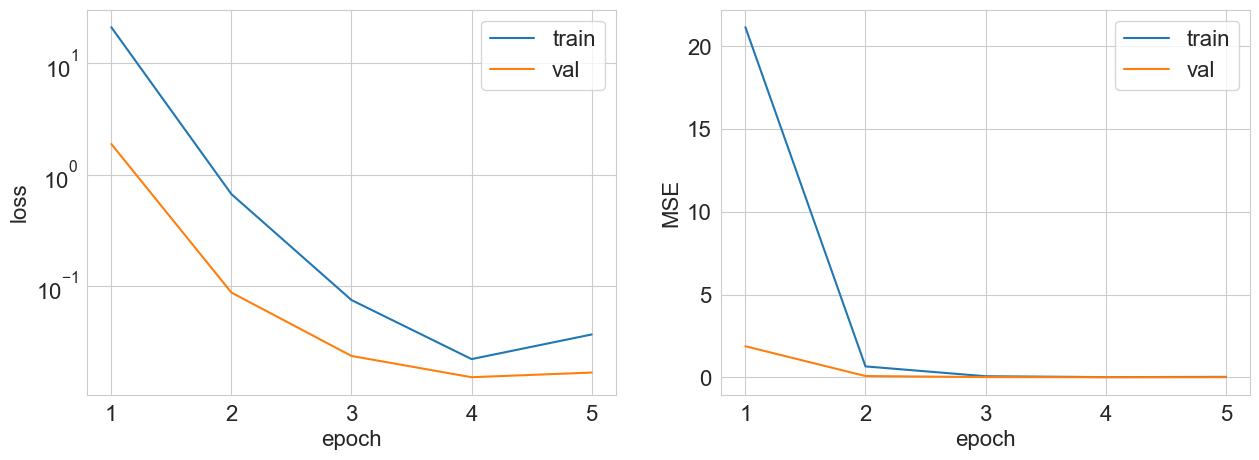

 denorm Adam MSE5 = 131.60337259082502


/var/folders/wc/8zvs74g54nn3_q_d9hhczqyh0000gn/T/ipykernel_19840/2106937877.py:94: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([sgd_mses, adam_mses], labels=['sdg+momentum', 'Adam'])


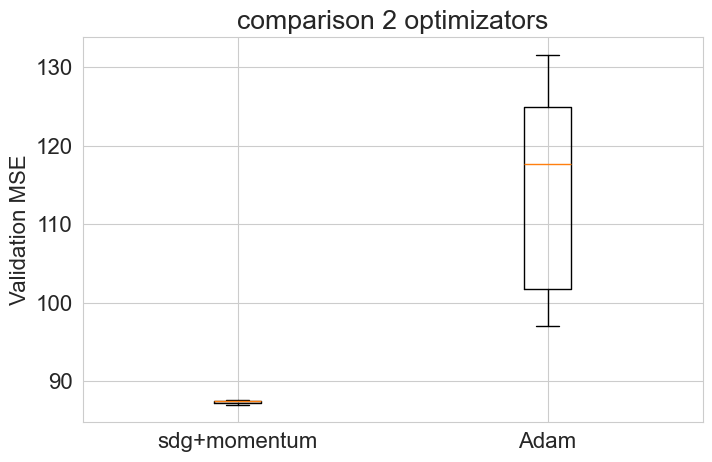

In [16]:
## я сделал нормализацию так как без нее просто не генерируются mse для sdg (везде выводит nan)

sgd_mses = []
adam_mses = []

for j in range(5): 
    
    
    X_train_scale = scaler.fit_transform(X_train)
    X_test_scale  = scaler.transform(X_test)
    
    y_train_new = normalize(y_train).reshape(-1, 1)
    y_test_new  = normalize(y_test).reshape(-1, 1)
    
    train_loader = mm.DataLoader(X_train_scale, y_train_new, batch_size=64, shuffle=True)
    test_loader  = mm.DataLoader(X_test_scale,  y_test_new,  batch_size=64, shuffle=False)

    model = mm.Sequential(
        mm.Linear(X_train.shape[1], 128),
        mm.ReLU(),
        mm.Linear(128, 1),
    )
    
    optimizer = mm.SGD(model, lr=1e-3, momentum = 0.9 )
    criterion  = mm.MSELoss()
    
    metric = lambda p, y: np.mean((p - y)**2)
    
    
    num_epochs = 5
    
    train_mse, val_mse, train_losses, val_losses, train_metrics, val_metrics = train_and_validate(model, optimizer, criterion, metric, train_loader, test_loader, num_epochs, verbose=False)
    
    plot_losses(train_losses, train_metrics, val_losses, val_metrics)

    predictions = []
    targets = []
    for X_batch, y_batch in test_loader:
        predictions.append(model(X_batch))
        targets.append(y_batch)
    
    predictions = np.vstack(predictions)          
    targets = np.vstack(targets)       
    
    denorm_predictions = denormalize(predictions)
    denorm_targets = denormalize(targets)
    
    real_mse = np.mean((denorm_predictions - denorm_targets)**2)
    print(f' denorm SDG MSE{j+1} = {real_mse}')
    
    sgd_mses.append(real_mse)

for j in range(5):
    y_train_new = normalize(y_train).reshape(-1, 1)
    y_test_new  = normalize(y_test).reshape(-1, 1)
    
    train_loader = mm.DataLoader(X_train, y_train_new, batch_size=64, shuffle=True)
    test_loader  = mm.DataLoader(X_test,  y_test_new,  batch_size=64, shuffle=False)
    
    model = mm.Sequential(
        mm.Linear(X_train.shape[1], 128),
        mm.ReLU(),
        mm.Linear(128, 1),
    )
    
    optimizer = mm.Adam(model, lr=1e-3)
    criterion  = mm.MSELoss()
    
    metric = lambda p, y: np.mean((p - y)**2)
    
    
    num_epochs = 5
    
    train_mse, val_mse, train_losses, val_losses, train_metrics, val_metrics = train_and_validate(model, optimizer, criterion, metric, train_loader, test_loader, num_epochs, verbose=False)
    
    plot_losses(train_losses, train_metrics, val_losses, val_metrics)
    predictions = []
    targets = []
    for X_batch, y_batch in test_loader:
        predictions.append(model(X_batch))
        targets.append(y_batch)
    
    predictions = np.vstack(predictions)          
    targets = np.vstack(targets)       
    
    denorm_predictions = denormalize(predictions)
    denorm_targets = denormalize(targets)
    
    real_mse = np.mean((denorm_predictions - denorm_targets)**2)
    print(f' denorm Adam MSE{j+1} = {real_mse}')
    adam_mses.append(real_mse)

plt.figure(figsize=(8, 5))
plt.boxplot([sgd_mses, adam_mses], labels=['sdg+momentum', 'Adam'])
plt.ylabel('Validation MSE')
plt.title('comparison 2 optimizators')
plt.grid(True)
plt.show()




видимо что при нормировке adam получилось хуже чем sgd 

**Задание 2.2 (1 балл).** Теперь сделаем нашу нейронную сеть более сложной. Попробуйте сделать сеть:

- более широкой (то есть увеличить размерность скрытого слоя, например, вдвое)
- более глубокой (то есть добавить еще один скрытый слой)

Опишите, как увеличение числа параметров модели влияет на качество на обучающей и валидационной выборках.

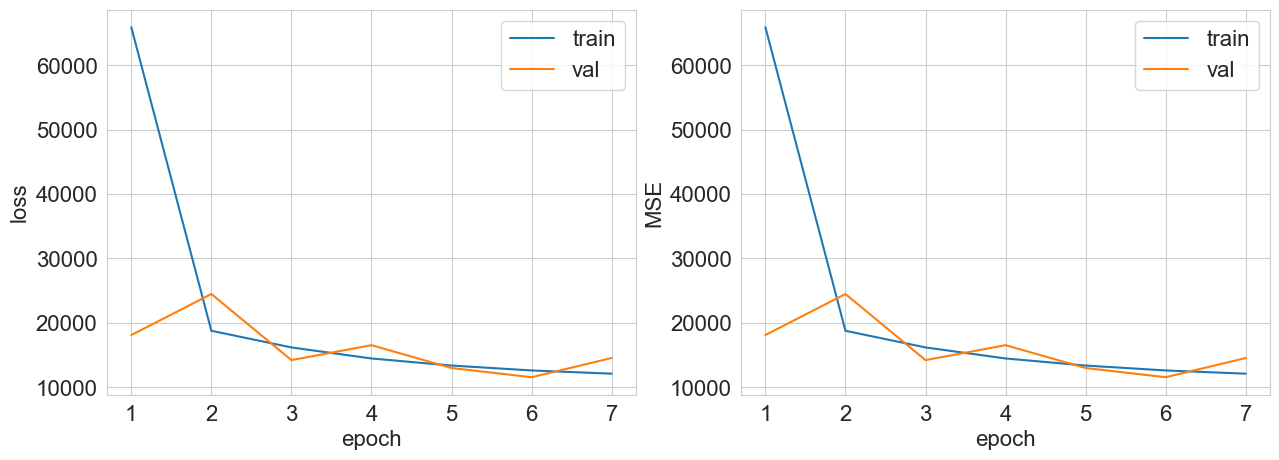

 MSE4 = 14543.767729864512


/var/folders/wc/8zvs74g54nn3_q_d9hhczqyh0000gn/T/ipykernel_19840/2290858223.py:67: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([wide_val_mses, deep_val_mses], labels=['Wide', 'Deep'])


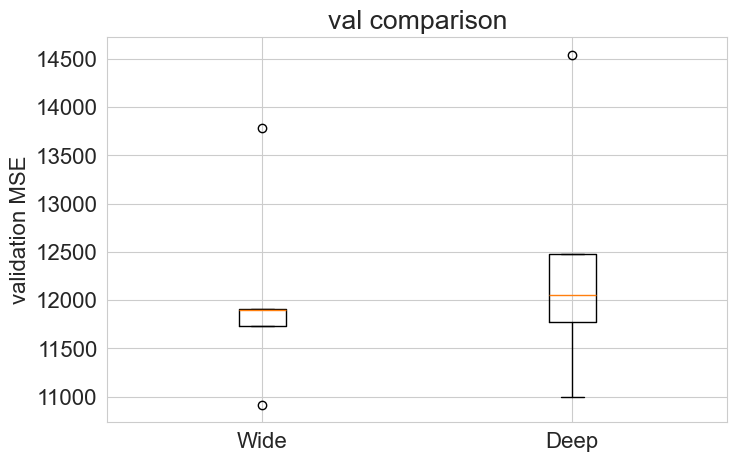

/var/folders/wc/8zvs74g54nn3_q_d9hhczqyh0000gn/T/ipykernel_19840/2290858223.py:74: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([wide_train_mses, deep_train_mses], labels=['Wide', 'Deep'])


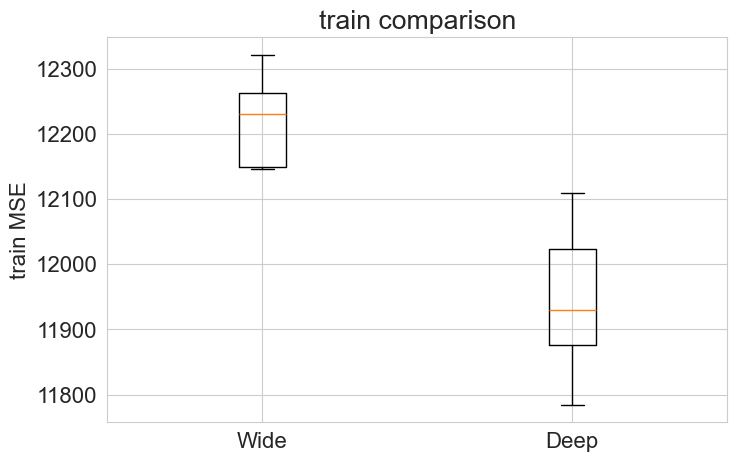

In [19]:
wide_val_mses = []
wide_train_mses = []
deep_val_mses = []
deep_train_mses = []


for j in range(5):
    y_train_new = y_train.reshape(-1, 1)
    y_test_new  = y_test.reshape(-1, 1)
    
    train_loader = mm.DataLoader(X_train, y_train_new, batch_size=64, shuffle=True)
    test_loader  = mm.DataLoader(X_test,  y_test_new,  batch_size=64, shuffle=False)
    
    model = mm.Sequential(
        mm.Linear(X_train.shape[1], 300),
        mm.ReLU(),
        mm.Linear(300, 1),
    )
    
    optimizer = mm.Adam(model, lr=1e-3)
    criterion  = mm.MSELoss()
    
    metric = lambda p, y: np.mean((p - y)**2)
    
    
    num_epochs = 7
    
    train_mse, val_mse, train_losses, val_losses, train_metrics, val_metrics = train_and_validate(model, optimizer, criterion, metric, train_loader, test_loader, num_epochs, verbose=False)
    
    plot_losses(train_losses, train_metrics, val_losses, val_metrics)
    print(f' MSE{j+1} = {val_mse}')
    wide_train_mses.append(train_mse)
    wide_val_mses.append(val_mse)

for j in range(5):
    y_train_new = y_train.reshape(-1, 1)
    y_test_new  = y_test.reshape(-1, 1)
    
    train_loader = mm.DataLoader(X_train, y_train_new, batch_size=64, shuffle=True)
    test_loader  = mm.DataLoader(X_test,  y_test_new,  batch_size=64, shuffle=False)
    
    model = mm.Sequential(
        mm.Linear(X_train.shape[1], 128),
        mm.ReLU(),
        mm.Linear(128, 64),
        mm.ReLU(),
        mm.Linear(64, 1),
    )
    
    optimizer = mm.Adam(model, lr=1e-3)
    criterion  = mm.MSELoss()
    
    metric = lambda p, y: np.mean((p - y)**2)
    
    
    num_epochs = 7
    
    train_mse, val_mse, train_losses, val_losses, train_metrics, val_metrics = train_and_validate(model, optimizer, criterion, metric, train_loader, test_loader, num_epochs, verbose=False)
    
    plot_losses(train_losses, train_metrics, val_losses, val_metrics)
    print(f' MSE{j} = {val_mse}')
    deep_train_mses.append(train_mse)
    deep_val_mses.append(val_mse)


plt.figure(figsize=(8, 5))
plt.boxplot([wide_val_mses, deep_val_mses], labels=['Wide', 'Deep'])
plt.ylabel('validation MSE')
plt.title('val comparison')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.boxplot([wide_train_mses, deep_train_mses], labels=['Wide', 'Deep'])
plt.ylabel('train MSE')
plt.title('train comparison')
plt.grid(True)
plt.show()

In [32]:
print(np.array(wide_val_mses) - np.array(deep_val_mses),
np.array(wide_train_mses) - np.array(deep_train_mses))

[ 3178.51107126   462.0030976  10931.19242007 -4946.25954125
  -494.80346226] [198.48040435 -29.64747713 671.71460155   9.65861799 333.94983417]


ну вообще вроде норм, mse получились лучше чем в первой части этого дз (там было 300к). очень хорошо видно, что из-за большого кол-ва параметров в широкой моделе идет переобучение на тестовой выборке и подгон под собственно тест. глубокая же модель лучше описывает сложные зависимости, видно что ее мсе на валидационной получился чуть ниже чем на тестовой.

**Задание 2.3 (1 балл).** Как вы должны были заметить, более сложная модель стала сильнее переобучаться. Попробуем разные методы регуляризации, чтобы бороться с переобучением. Проведите два эксперимента:

- Добавьте слой дропаута с параметром $p=0.2$ после каждого линейного слоя, кроме последнего.
- Попробуйте batch-нормализацию вместо дропаута. Строго говоря, batch-нормализация не является методом регуляризации, но никто не запрещает нам экспериментировать с ней.

Опишите результаты экспериментов. 

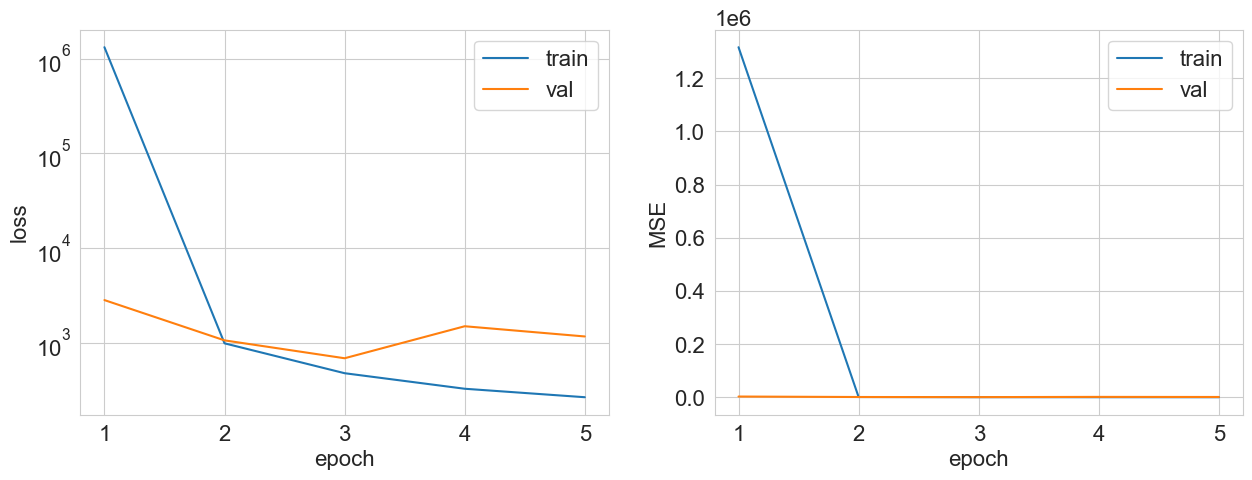

 MSE4 = 1172.4709136917245


/var/folders/wc/8zvs74g54nn3_q_d9hhczqyh0000gn/T/ipykernel_19840/1534012942.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([dropout_val_mses, bn_val_mses], labels=['dropout', 'batchnorm'])


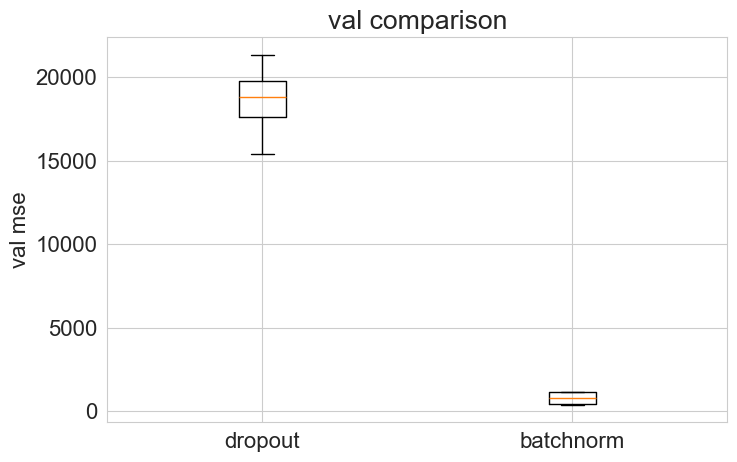

/var/folders/wc/8zvs74g54nn3_q_d9hhczqyh0000gn/T/ipykernel_19840/1534012942.py:80: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([dropout_train_mses, bn_train_mses], labels=['dropout', 'batchNorm'])


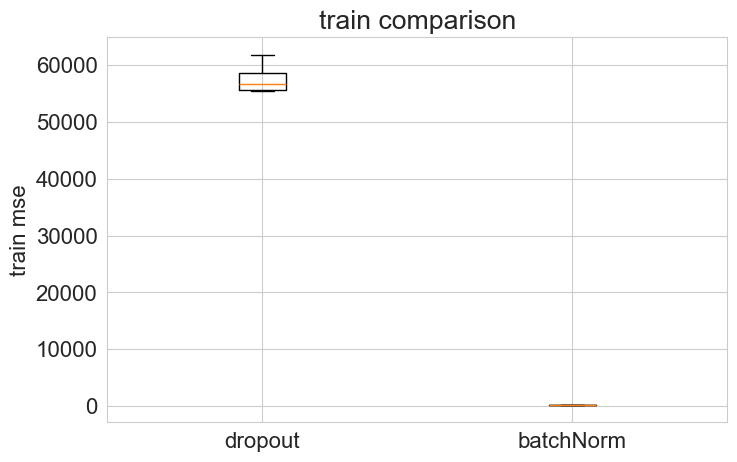

In [20]:
dropout_train_mses = []
dropout_val_mses  = []
bn_train_mses = []
bn_val_mses = []


for j in range(4):
    y_train_new = y_train.reshape(-1, 1)
    y_test_new  = y_test.reshape(-1, 1)
    
    train_loader = mm.DataLoader(X_train, y_train_new, batch_size=64, shuffle=True)
    test_loader  = mm.DataLoader(X_test,  y_test_new,  batch_size=64, shuffle=False)
    
    model = mm.Sequential(
        mm.Linear(X_train.shape[1], 128),
        mm.Dropout(p = 0.2),
        mm.ReLU(),
        mm.Linear(128, 64),
        mm.Dropout(p = 0.2),
        mm.ReLU(),
        mm.Linear(64, 1),
    )
    
    optimizer = mm.Adam(model, lr=1e-3)
    criterion  = mm.MSELoss()
    
    metric = lambda p, y: np.mean((p - y)**2)
    
    
    num_epochs = 5
    
    train_mse, val_mse, train_losses, val_losses, train_metrics, val_metrics = train_and_validate(model, optimizer, criterion, metric, train_loader, test_loader, num_epochs, verbose=False)
    
    plot_losses(train_losses, train_metrics, val_losses, val_metrics)
    print(f' MSE{j+1} = {val_mse}')
    dropout_train_mses.append(train_mse)
    dropout_val_mses.append(val_mse)

for j in range(4):
    y_train_new = y_train.reshape(-1, 1)
    y_test_new  = y_test.reshape(-1, 1)
    
    train_loader = mm.DataLoader(X_train, y_train_new, batch_size=64, shuffle=True)
    test_loader  = mm.DataLoader(X_test,  y_test_new,  batch_size=64, shuffle=False)
    
    model = mm.Sequential(
        mm.Linear(X_train.shape[1], 128),
        mm.BatchNormalization(128),
        mm.ReLU(),
        mm.Linear(128, 64),
        mm.BatchNormalization(64),
        mm.ReLU(),
        mm.Linear(64, 1),
    )
    
    optimizer = mm.Adam(model, lr=1e-3)
    criterion  = mm.MSELoss()
    
    metric = lambda p, y: np.mean((p - y)**2)
    
    
    num_epochs = 5
    
    train_mse, val_mse, train_losses, val_losses, train_metrics, val_metrics = train_and_validate(model, optimizer, criterion, metric, train_loader, test_loader, num_epochs, verbose=False)
    
    plot_losses(train_losses, train_metrics, val_losses, val_metrics)
    print(f' MSE{j+1} = {val_mse}')
    bn_train_mses.append(train_mse)
    bn_val_mses.append(val_mse)


plt.figure(figsize=(8, 5))
plt.boxplot([dropout_val_mses, bn_val_mses], labels=['dropout', 'batchnorm'])
plt.ylabel('val mse')
plt.title('val comparison')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.boxplot([dropout_train_mses, bn_train_mses], labels=['dropout', 'batchNorm'])
plt.ylabel('train mse')
plt.title('train comparison')
plt.grid(True)
plt.show()

In [34]:
print(np.array(bn_train_mses))

[261.99811485 261.80227933 261.15875733 244.47752842]


видно что батчнорм намного лучше справляется с поставленной задачей нежели дропаут. что на обучающей что на валидационной выборке результат кардинально лучше, что связано с тем, что батчнорм нормирует входные данные. как мы видели выше это ключевой шаг, чтобы сделать мсе ниже

**Задание 2.4 (1.5 балла).** Теперь, когда мы определились с выбором архитектуры нейронной сети, пора заняться рутиной DL-инженера &mdash; перебором гиперпараметров. Подберите оптимальное значение lr по значению MSE на валидации (по логарифмической сетке, достаточно посмотреть 3-4 значения), можете воспользоваться `verbose=False` в функции `train_and_validate`. Затем подберите оптимальное значение weight decay для данного lr (тоже по логарифмической сетке, типичные значения этого параметра лежат в диапазоне $[10^{-6}, 10^{-3}]$, но не забудьте включить нулевое значение в сетку). Постройте графики зависимости MSE на трейне и на валидации от значений параметров. Прокомментируйте получившиеся зависимости.

lr=1e-06, train_mse=3989431.040694586, val_mse=3989521.0599697214
lr=1e-05, train_mse=3945336.3702941886, val_mse=3937674.6054445878
lr=0.0001, train_mse=1643557.0870502351, val_mse=1266496.4457322676
lr=0.001, train_mse=266.3219557121884, val_mse=765.2980358697776
lr=0.01, train_mse=93.42861524549343, val_mse=118.3503748866717


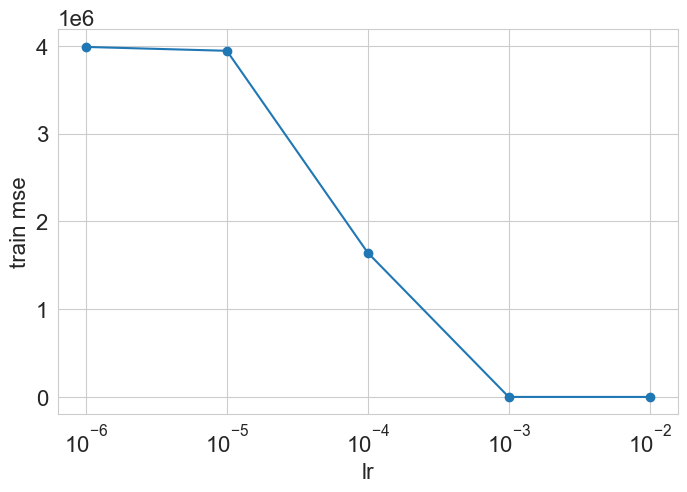

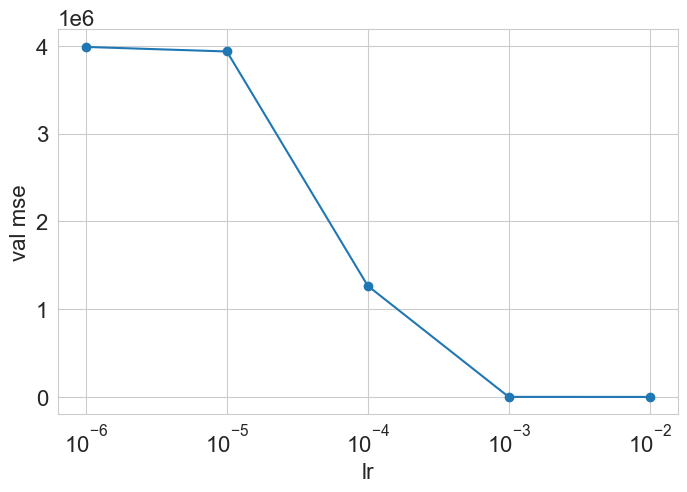

In [21]:
lrs = [1e-6,1e-5, 1e-4,1e-3,1e-2]

lr_train_mse = []
lr_val_mse = []

for lr in lrs:

    y_train_new = y_train.reshape(-1, 1)
    y_test_new = y_test.reshape(-1, 1)

    train_loader = mm.DataLoader(X_train, y_train_new, batch_size=64, shuffle=True)
    test_loader = mm.DataLoader(X_test, y_test_new, batch_size=64, shuffle=False)

    model = mm.Sequential(
        mm.Linear(X_train.shape[1], 128),
        mm.BatchNormalization(128),
        mm.ReLU(),
        mm.Linear(128, 64),
        mm.BatchNormalization(64),
        mm.ReLU(),
        mm.Linear(64, 1),
    )

    optimizer = mm.Adam(model, lr=lr)
    criterion = mm.MSELoss()
    metric = lambda p, y: np.mean((p - y)**2)

    num_epochs = 5

    train_mse, val_mse, train_losses, val_losses, train_metrics, val_metrics = train_and_validate(model, optimizer, criterion, metric, train_loader, test_loader, num_epochs, verbose=False)

 
    lr_train_mse.append(train_mse)
    lr_val_mse.append(val_mse)

    print(f"lr={lr}, train_mse={train_mse}, val_mse={val_mse}")

plt.figure(figsize=(8,5))
plt.plot(lrs, lr_train_mse, marker='o')
plt.xscale('log')
plt.xlabel('lr')
plt.ylabel('train mse')
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(lrs, lr_val_mse, marker='o')
plt.xscale('log')
plt.xlabel('lr')
plt.ylabel('val mse')
plt.grid(True)
plt.show()

wd=1e-07, train_mse=93.66832553520064, val_mse=85.09277814696702
wd=1e-06, train_mse=93.77062785126887, val_mse=91.66134794461345
wd=1e-05, train_mse=97.70326316050075, val_mse=96.76918489184922
wd=0.0001, train_mse=94.64141742073875, val_mse=92.81277032234452
wd=0.001, train_mse=96.42880497831739, val_mse=87.69829188668898


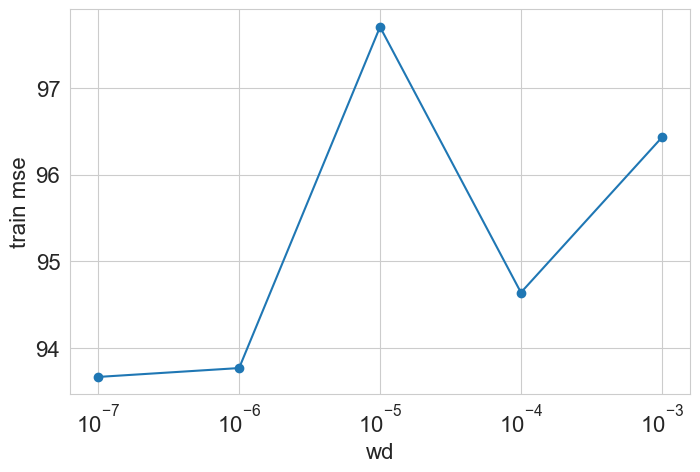

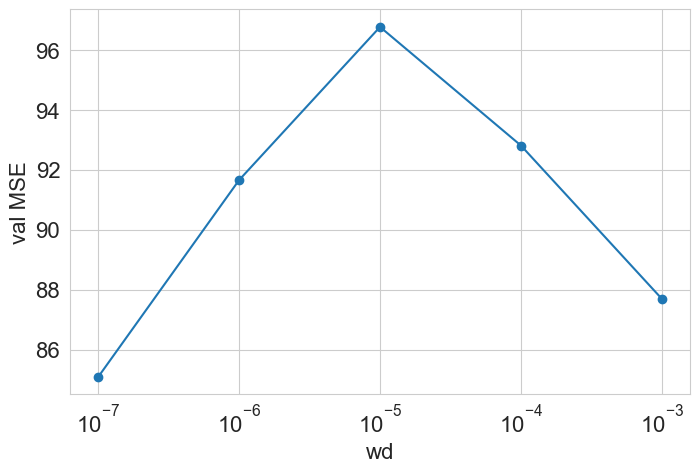

In [23]:
wds = [1e-7,1e-6, 1e-5, 1e-4, 1e-3]

wd_train_mse = []
wd_val_mse = []

for wd in wds:

    train_loader = mm.DataLoader(X_train, y_train.reshape(-1,1), batch_size=64, shuffle=True)
    test_loader = mm.DataLoader(X_test, y_test.reshape(-1,1), batch_size=64, shuffle=False)

    model = mm.Sequential(
        mm.Linear(X_train.shape[1], 128),
        mm.BatchNormalization(128),
        mm.ReLU(),
        mm.Linear(128, 64),
        mm.BatchNormalization(64),
        mm.ReLU(),
        mm.Linear(64, 1),
    )

    optimizer = mm.Adam(model, lr=1e-2, weight_decay=wd)
    criterion = mm.MSELoss()
    metric = lambda p, y: np.mean((p - y)**2)

    num_epochs = 5

    train_mse, val_mse, train_losses, val_losses, train_metrics, val_metrics = train_and_validate(model, optimizer, criterion, metric, train_loader, test_loader, num_epochs, verbose=False)

    wd_train_mse.append(train_mse)
    wd_val_mse.append(val_mse)

    print(f"wd={wd}, train_mse={train_mse}, val_mse={val_mse}")


plt.figure(figsize=(8,5))
plt.plot(wds, wd_train_mse, marker='o')
plt.xscale('log')
plt.xlabel('wd')
plt.ylabel('train mse')
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(wds, wd_val_mse, marker='o')
plt.xscale('log')
plt.xlabel('wd')
plt.ylabel('val MSE')
plt.grid(True)
plt.show()

Видим, что с ростом lr у нас лосс падает. ситуация же с wd обратная, с его ростом у нас лосс растет. то есть очень важен накопленный градиент

Как вы могли заметить, еще одна рутина DL-инженера &mdash; утомительное ожидание обучения моделей.

**Задание 2.5 (0.5 балла).** Мы провели большое число экспериментов и подобрали оптимальную архитектуру и гиперпараметры. Пришло время обучить модель на полной обучающей выборке, померять качество на тестовой выборке и сравнить с бейзлайнами. Проделайте это. 

видимо что все-таки мы добилсь результата лучше, чем у бейзлан (победа! я рад). нормализация решает, так как выходные и входные данные довольно разрознены

In [24]:
y_train_new = y_train.reshape(-1, 1)
y_test_new = y_test.reshape(-1, 1)

train_loader = mm.DataLoader(X_train, y_train_new, batch_size=64, shuffle=True)
test_loader = mm.DataLoader(X_test, y_test_new, batch_size=64, shuffle=False)

model = mm.Sequential(
    mm.Linear(X_train.shape[1], 128),
    mm.BatchNormalization(128),
    mm.ReLU(),
    mm.Linear(128, 64),
    mm.BatchNormalization(64),
    mm.ReLU(),
    mm.Linear(64, 1),
)

optimizer = mm.Adam(model, lr=1e-2, weight_decay=1e-7)
criterion = mm.MSELoss()
metric = lambda p, y: np.mean((p-y)**2)

num_epochs = 10 

train_mse, val_mse, train_losses, val_losses, train_metrics, val_metrics = train_and_validate(model, optimizer, criterion, metric, train_loader, test_loader, num_epochs, verbose=False)

print(f'probably best mse on train {train_mse}')
print(f'probably best mse on on val {val_mse}')


y_pred_simple = y_train_new.mean()
val_mse_simple = np.mean((y_test_new-y_pred_simple)**2)
train_mse_simple = np.mean((y_train_new-y_pred_simple)**2)

print(f'baseline (mean) mse on train {train_mse_simple}')
print(f'baseline (mean) mse on val {val_mse_simple}')

from sklearn.linear_model import LinearRegression

linreg = LinearRegression()
linreg.fit(X_train, y_train)
linreg_pred = linreg.predict(X_test)
val_linreg_mse = np.mean((linreg_pred - y_test)**2)
print(f'baseline (linreg) mse on val {val_mse_simple}')

probably best mse on train 89.18992247667019
probably best mse on on val 81.90147900921586
baseline (mean) mse on train 120.10888877325021
baseline (mean) mse on val 117.62626181741031
baseline (linreg) mse on val 117.62626181741031
